# WINE CLASSIFICATION USING ARTIFICIAL NEURAL NETWORK (ANN)

## IMPORT LIBRARIES

In [1]:
import numpy as np # mathematical operations and array handling
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns # better visualization of confusion matrix
from tensorflow.keras.models import Sequential # model allows stacking layers one after another
from tensorflow.keras.layers import     Input, Dense   # Dense → fully connected classification layers
from tensorflow.keras.callbacks import EarlyStopping # prevents overfitting
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics
from sklearn.datasets import load_wine # Dataset utilities (Wine dataset is a built-in sklearn dataset)
from sklearn.model_selection import train_test_split # Splitting dataset into training and testing parts
from sklearn.preprocessing import StandardScaler # StandardScaler is used for feature scaling

## LOAD DATASET

- Wine dataset contains chemical analysis of wines
- Goal: classify wine into 3 types (class 0, 1, 2)

In [2]:
data = load_wine()

X = data.data      # input features (chemical properties)
y = data.target    # output labels (wine class)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (178, 13)
Output shape: (178,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (142, 13)
Testing shape: (36, 13)


## FEATURE SCALING
Neural networks are sensitive to feature scale

Without scaling: features like magnesium (large values) dominate smaller features

We apply Standardization:

`z = (x - μ) / σ`

where:
- μ = mean of feature
- σ = standard deviation

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## BUILD ANN MODEL

- **Hidden Layer 1:** Each neuron computes weighted sum of inputs -> `z = w1x1 + w2x2 + ... + wnxn + b`
- **Hidden Layer 2** Learns more complex feature combinations
- **Hidden Layer 3** Further compresses learned representation
- **Dense:** Output Layer
    - **Softmax** converts outputs into probabilities -> `p(i) = e^(xi) / Σ e^(xj)`
    - Sum of all outputs = 1
    - Output = probability for each wine class

In [6]:
model = Sequential([

    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"), # Hidden Layer 1
    Dense(16, activation="relu"), # Hidden Layer 2
    Dense(8, activation="relu"),  # Hidden Layer 3
    Dense(3, activation="softmax") # Output LAyer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

## COMPILE MODEL

**Optimizer:** Adam combines Momentum and Adaptive learning rate
  - Weight update idea: `θ = θ - α * gradient`

**Loss function:** Sparse Categorical Crossentropy
  - `Loss = -log(p_true)` -> where p_true = predicted probability of correct class

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## TRAIN MODEL

- Early stopping prevents overfitting
- Stops training when validation loss stops improving

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.3982 - loss: 1.0854 - val_accuracy: 0.6207 - val_loss: 1.0191
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6018 - loss: 1.0204 - val_accuracy: 0.7931 - val_loss: 0.9794
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7168 - loss: 0.9699 - val_accuracy: 0.8276 - val_loss: 0.9367
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7522 - loss: 0.9212 - val_accuracy: 0.8966 - val_loss: 0.8878
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8142 - loss: 0.8689 - val_accuracy: 0.8966 - val_loss: 0.8282
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8319 - loss: 0.8110 - val_accuracy: 0.8966 - val_loss: 0.7557
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8407 - loss: 0.7560 - val_accuracy: 0.8966 - val_loss: 0.6828
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8673 - loss: 0.6953 - val_accuracy: 0.9310 - val_loss: 0.6150

## EVALUATION
- Precision = TP / (TP + FP)
- Recall    = TP / (TP + FN)
- F1 Score  = 2PR / (P + R)

In [10]:
# ACCURACY AND LOSS
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss, 4))
print(f"Test Accuracy: {test_acc:4f} -> {test_acc:2%}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9444 - loss: 0.1093
Test Loss: 0.1093
Test Accuracy: 0.944444 -> 94.444442%


In [11]:
# PREDICTIONS
y_prob = model.predict(X_test)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [12]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [13]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm

array([[12,  0,  0],
       [ 1, 13,  0],
       [ 0,  1,  9]])

## VISUALIZATIONS

### CONFUSION MATRIX

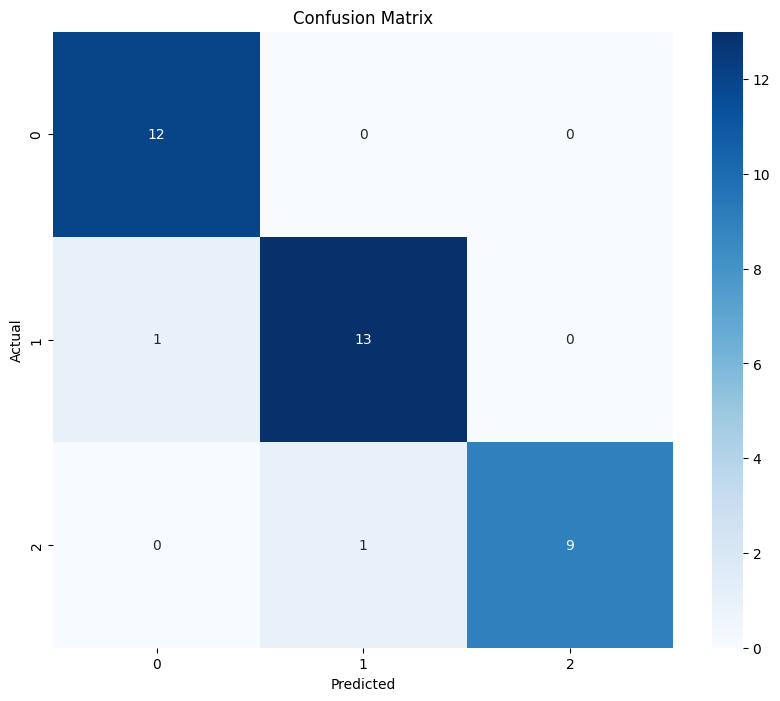

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
    )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### TRAINING CURVES

#### Loss Curve

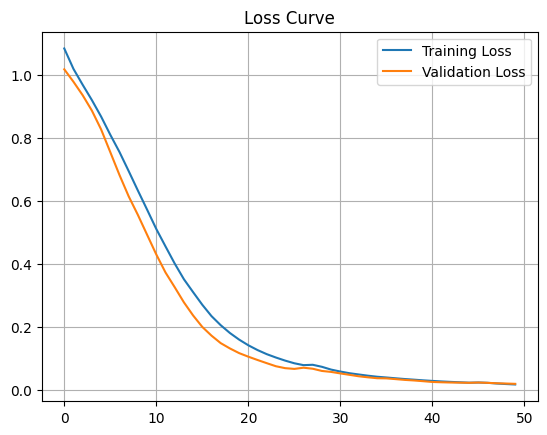

In [15]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

#### Accuracy Curve

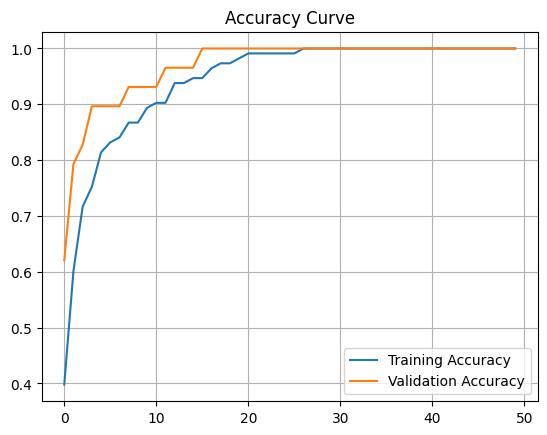

In [16]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

## WINE ANN SUMMARY:

1. ANN works on structured tabular data
2. Each neuron learns weighted combinations of features
3. StandardScaler ensures fair contribution of all features
4. Softmax outputs probability distribution over 3 classes

**Neuron:**
z = Σ(wi * xi) + b

**Activation:**
a = ReLU(z) or Softmax(z)

**Loss:**
L = -log(p_true)

**Final result:**
Model learns chemical patterns that distinguish wine types